<a href="https://colab.research.google.com/github/DeepanshuSharma1607/langgraph/blob/main/langgraph_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install uv
!uv pip install langchain-mistralai

Using Python 3.12.13 environment at: /usr
Checked 1 package in 176ms


In [ ]:
from langchain_mistralai import ChatMistralAI
from langchain_core.messages import (
    AIMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage
)
from langgraph.graph import StateGraph , MessagesState , START , END , add_messages
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import display , Image
import requests
from rich import print
from pprint import pprint
from langchain.tools import tool

In [ ]:
CHAT_MISTRAL_API_KEY = "put your api key here"

In [ ]:
llm = ChatMistralAI(
    model="mistral-small-2506",
    api_key= CHAT_MISTRAL_API_KEY
)

In [ ]:
result = llm.invoke("hello")

In [ ]:
print(result)

AIMessage(
    content='Hello! 😊 How can I assist you today?',
    additional_kwargs={},
    response_metadata={
        'token_usage': {
            'prompt_tokens': 4,
            'total_tokens': 17,
            'completion_tokens': 13,
            'prompt_tokens_details': {'cached_tokens': 0}
        },
        'model_name': 'mistral-small-2506',
        'model': 'mistral-small-2506',
        'finish_reason': 'stop',
        'model_provider': 'mistralai'
    },
    id='lc_run--019f2dde-3a19-7de1-8a06-af3b4c1c5b02-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={'input_tokens': 4, 'output_tokens': 13, 'total_tokens': 17}
)

In [ ]:
(llm.invoke("hello")).pretty_print()

================================== Ai Message ==================================

Hello! 😊 How can I help you today?


In [ ]:
@tool
def multiply(a : int , b  :int):
  """
Multiply a and b

Args :
a : first int
b : second int
  """
  return a * b

@tool
def divide(a : int , b  :int):
  """
Divide a and b

Args :
a : first int
b : second int
  """
  return a / b

@tool
def add(a : int , b  :int):
  """
Add a and b

Args :
a : first int
b : second int
  """
  return a + b

@tool
def subtract(a : int , b  :int):
  """
Subtract a and b

Args :
a : first int
b : second int
  """
  return a - b

In [ ]:
tools = [add,subtract,multiply,divide]
llm = llm.bind_tools(tools)

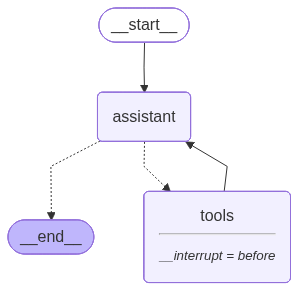

In [ ]:
from IPython.display import Image, display

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode

from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# Node
def assistant(state: MessagesState):
   return {"messages": [llm.invoke([sys_msg] + state["messages"])]}

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine the control flow
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")

memory = MemorySaver()
graph = builder.compile(interrupt_before=["tools"], checkpointer=memory)

# Show
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))


In [ ]:
initial_input = {"messages": HumanMessage(content="Multiply 2 and 3")}

# Thread
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()


================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (LaDsge8dM)
 Call ID: LaDsge8dM
  Args:
    a: 2
    b: 3


In [ ]:
state = graph.get_state(thread)
state.next

('tools',)

In [ ]:
state = graph.get_state_history(thread)
state

<generator object Pregel.get_state_history at 0x7f84f360bcc0>

In [ ]:
for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  multiply (LaDsge8dM)
 Call ID: LaDsge8dM
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The result of multiplying 2 and 3 is 6.


In [ ]:
# Input
initial_input = {"messages": HumanMessage(content="Multiply 2 and 3")}

# Thread
thread = {"configurable": {"thread_id": "2"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

# Get user feedback
user_approval = input("Do you want to call the tool? (yes/no): ")

# Check approval
if user_approval.lower() == "yes":

    # If approved, continue the graph execution
    for event in graph.stream(None, thread, stream_mode="values"):
        event['messages'][-1].pretty_print()

else:
    print("Operation cancelled by user.")

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (UZ3fTyril)
 Call ID: UZ3fTyril
  Args:
    a: 2
    b: 3
Do you want to call the tool? (yes/no): yes
================================== Ai Message ==================================
Tool Calls:
  multiply (UZ3fTyril)
 Call ID: UZ3fTyril
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The result of multiplying 2 and 3 is 6.


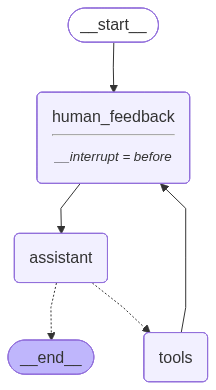

In [ ]:
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# no-op node that should be interrupted on
def human_feedback(state: MessagesState):
    pass

# Assistant node
def assistant(state: MessagesState):
   return {"messages": [llm.invoke([sys_msg] + state["messages"])]}

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))
builder.add_node("human_feedback", human_feedback)

# Define edges: these determine the control flow
builder.add_edge(START, "human_feedback")
builder.add_edge("human_feedback", "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "human_feedback")

memory = MemorySaver()
graph = builder.compile(interrupt_before=["human_feedback"], checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# Input
initial_input = {"messages": "Multiply 2 and 3"}

# Thread
thread = {"configurable": {"thread_id": "5"}}
ms=[]
# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="values"):
  ms.append(event["messages"][-1])
  event["messages"][-1].pretty_print()

# Get user input
user_input = input("Tell me how you want to update the state: ")

# We now update the state as if we are the human_feedback node
graph.update_state(thread, {"messages": user_input}, as_node="human_feedback")

# Continue the graph execution
for event in graph.stream(None, thread, stream_mode="values"):
  ms.append(event["messages"][-1])
  event["messages"][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
Tell me how you want to update the state: yes
================================ Human Message =================================

yes
================================== Ai Message ==================================
Tool Calls:
  multiply (bNC6fJWVV)
 Call ID: bNC6fJWVV
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [ ]:
for event in graph.stream(None, thread, stream_mode="values"):
  ms.append(event["messages"][-1])
  event["messages"][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The result of multiplying 2 and 3 is 6.


In [ ]:
print(ms)

[
    HumanMessage(
        content='Multiply 2 and 3',
        additional_kwargs={},
        response_metadata={},
        id='8f98e6bf-2ef3-4ca8-a0bb-901e9fe681f3'
    ),
    HumanMessage(
        content='yes',
        additional_kwargs={},
        response_metadata={},
        id='9729629e-449c-4550-8d8a-b09ff7eaff74'
    ),
    AIMessage(
        content='',
        additional_kwargs={
            'tool_calls': [
                {
                    'id': 'bNC6fJWVV',
                    'type': 'function',
                    'function': {'name': 'multiply', 'arguments': '{"a": 2, "b": 3}'},
                    'index': 0
                }
            ]
        },
        response_metadata={
            'token_usage': {
                'prompt_tokens': 354,
                'total_tokens': 371,
                'completion_tokens': 17,
                'prompt_tokens_details': {'cached_tokens': 0}
            },
            'model_name': 'mistral-small-2506',
            'model': 'mistral-small-2506',
            'finish_reason': 'tool_calls',
            'model_provider': 'mistralai'
        },
        id='lc_run--019f2dde-6143-70c2-ad43-19d9887a70ef-0',
        tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'bNC6fJWVV', 'type': 'tool_call'}],
        invalid_tool_calls=[],
        usage_metadata={'input_tokens': 354, 'output_tokens': 17, 'total_tokens': 371}
    ),
    ToolMessage(
        content='6',
        name='multiply',
        id='7d5bac39-761d-42a8-8818-e1472e99c3a3',
        tool_call_id='bNC6fJWVV'
    ),
    ToolMessage(
        content='6',
        name='multiply',
        id='7d5bac39-761d-42a8-8818-e1472e99c3a3',
        tool_call_id='bNC6fJWVV'
    ),
    AIMessage(
        content='The result of multiplying 2 and 3 is 6.',
        additional_kwargs={},
        response_metadata={
            'token_usage': {
                'prompt_tokens': 392,
                'total_tokens': 406,
                'completion_tokens': 14,
                'prompt_tokens_details': {'cached_tokens': 0}
            },
            'model_name': 'mistral-small-2506',
            'model': 'mistral-small-2506',
            'finish_reason': 'stop',
            'model_provider': 'mistralai'
        },
        id='lc_run--019f2dde-6338-76a3-bc77-25453a9646cb-0',
        tool_calls=[],
        invalid_tool_calls=[],
        usage_metadata={'input_tokens': 392, 'output_tokens': 14, 'total_tokens': 406}
    )
]

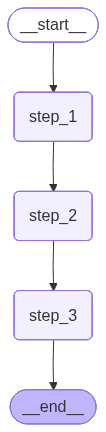

In [ ]:
from IPython.display import Image, display

from typing_extensions import TypedDict
from langgraph.checkpoint.memory import MemorySaver
from langgraph.errors import NodeInterrupt
from langgraph.graph import START, END, StateGraph

class State(TypedDict):
    input: str

def step_1(state: State) -> State:
    print("---Step 1---")
    return state

def step_2(state: State) -> State:
    # Let's optionally raise a NodeInterrupt if the length of the input is longer than 5 characters
    if len(state['input']) > 5:
        raise NodeInterrupt(f"Received input that is longer than 5 characters: {state['input']}")

    print("---Step 2---")
    return state

def step_3(state: State) -> State:
    print("---Step 3---")
    return state

builder = StateGraph(State)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)
builder.add_edge(START, "step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

# Set up memory
memory = MemorySaver()

# Compile the graph with memory
graph = builder.compile(checkpointer=memory)

# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [ ]:
initial_input = {"input": "hello world"}
thread_config = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread_config, stream_mode="values"):
    print(event)

{'input': 'hello world'}

---Step 1---

{'input': 'hello world'}

/tmp/ipykernel_2277/448469904.py:18: LangGraphDeprecatedSinceV10: NodeInterrupt is deprecated. Please use `langgraph.types.interrupt` instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  raise NodeInterrupt(f"Received input that is longer than 5 characters: {state['input']}")


{
    'input': 'hello world',
    '__interrupt__': (
        Interrupt(value='Received input that is longer than 5 characters: hello world', id='placeholder-id'),
    )
}

In [ ]:
for event in graph.stream(None, thread_config, stream_mode="values"):
    print(event)


{'input': 'hello world'}

/tmp/ipykernel_2277/448469904.py:18: LangGraphDeprecatedSinceV10: NodeInterrupt is deprecated. Please use `langgraph.types.interrupt` instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  raise NodeInterrupt(f"Received input that is longer than 5 characters: {state['input']}")


{
    'input': 'hello world',
    '__interrupt__': (
        Interrupt(value='Received input that is longer than 5 characters: hello world', id='placeholder-id'),
    )
}

In [ ]:
state = graph.update_state(thread_config,{"input":"hi"})
for event in graph.stream(None, thread_config, stream_mode="values"):
    print(event)

{'input': 'hi'}

---Step 2---

{'input': 'hi'}

---Step 3---

{'input': 'hi'}

In [ ]:
for event in graph.stream(None, thread_config, stream_mode="values"):
    print(event)

{'input': 'hi'}

In [ ]:
graph.get_state(thread_config)

StateSnapshot(values={'input': 'hi'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f177c1d-3757-6b8a-8004-94e99abf0a41'}}, metadata={'source': 'loop', 'step': 4, 'parents': {}}, created_at='2026-07-04T16:02:58.528118+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f177c1d-3748-6f96-8003-2f441f984be0'}}, tasks=(), interrupts=())

In [ ]:
@tool
def multiply(a : int , b  :int):
  """
Multiply a and b

Args :
a : first int
b : second int
  """
  return a * b

@tool
def divide(a : int , b  :int):
  """
Divide a and b

Args :
a : first int
b : second int
  """
  return a / b

@tool
def add(a : int , b  :int):
  """
Add a and b

Args :
a : first int
b : second int
  """
  return a + b

@tool
def subtract(a : int , b  :int):
  """
Subtract a and b

Args :
a : first int
b : second int
  """
  return a - b



In [ ]:
tools = [add,subtract,multiply,divide]
llm = llm.bind_tools(tools)

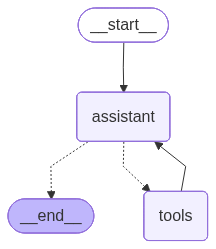

In [ ]:
from IPython.display import Image, display

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode

from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# Node
def assistant(state: MessagesState):
   return {"messages": [llm.invoke([sys_msg] + state["messages"])]}

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine the control flow
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")

memory = MemorySaver()
graph = builder.compile( checkpointer=memory)

# Show
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))


In [ ]:
# Input
initial_input = {"messages": HumanMessage(content="Multiply 2 and 3")}

# Thread
thread = {"configurable": {"thread_id": "8"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (IWSj4llIF)
 Call ID: IWSj4llIF
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The result of multiplying 2 and 3 is 6.


In [ ]:
# Input
initial_input = {"messages": HumanMessage(content="Multiply 2 and 3")}

# Thread
thread = {"configurable": {"thread_id": "8"}}
for event in graph.stream(initial_input, thread, stream_mode="values"):
    print(event['messages'][-1])

HumanMessage(
    content='Multiply 2 and 3',
    additional_kwargs={},
    response_metadata={},
    id='b2f663c7-38c8-4b38-91cd-9f8afb66f442'
)

AIMessage(
    content='The result of multiplying 2 and 3 is 6. Do you need any other assistance?',
    additional_kwargs={},
    response_metadata={
        'token_usage': {
            'prompt_tokens': 409,
            'total_tokens': 430,
            'completion_tokens': 21,
            'prompt_tokens_details': {'cached_tokens': 0}
        },
        'model_name': 'mistral-small-2506',
        'model': 'mistral-small-2506',
        'finish_reason': 'stop',
        'model_provider': 'mistralai'
    },
    id='lc_run--019f2dde-714b-7b92-a656-ed7174763ca7-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={'input_tokens': 409, 'output_tokens': 21, 'total_tokens': 430}
)

In [ ]:
print(graph.get_state({"configurable": {"thread_id": "8"}}))

StateSnapshot(
    values={
        'messages': [
            HumanMessage(
                content='Multiply 2 and 3',
                additional_kwargs={},
                response_metadata={},
                id='5f69be92-bd79-48ca-8047-417233fa12e0'
            ),
            AIMessage(
                content='',
                additional_kwargs={
                    'tool_calls': [
                        {
                            'id': 'IWSj4llIF',
                            'type': 'function',
                            'function': {'name': 'multiply', 'arguments': '{"a": 2, "b": 3}'},
                            'index': 0
                        }
                    ]
                },
                response_metadata={
                    'token_usage': {
                        'prompt_tokens': 352,
                        'total_tokens': 369,
                        'completion_tokens': 17,
                        'prompt_tokens_details': {'cached_tokens': 0}
                    },
                    'model_name': 'mistral-small-2506',
                    'model': 'mistral-small-2506',
                    'finish_reason': 'tool_calls',
                    'model_provider': 'mistralai'
                },
                id='lc_run--019f2dde-6cac-7631-89c6-c2668c1a8e75-0',
                tool_calls=[
                    {'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'IWSj4llIF', 'type': 'tool_call'}
                ],
                invalid_tool_calls=[],
                usage_metadata={'input_tokens': 352, 'output_tokens': 17, 'total_tokens': 369}
            ),
            ToolMessage(
                content='6',
                name='multiply',
                id='259983b6-dddf-4d41-a898-ac979702def2',
                tool_call_id='IWSj4llIF'
            ),
            AIMessage(
                content='The result of multiplying 2 and 3 is 6.',
                additional_kwargs={},
                response_metadata={
                    'token_usage': {
                        'prompt_tokens': 386,
                        'total_tokens': 400,
                        'completion_tokens': 14,
                        'prompt_tokens_details': {'cached_tokens': 320}
                    },
                    'model_name': 'mistral-small-2506',
                    'model': 'mistral-small-2506',
                    'finish_reason': 'stop',
                    'model_provider': 'mistralai'
                },
                id='lc_run--019f2dde-6f38-74a1-884f-67c670be41f1-0',
                tool_calls=[],
                invalid_tool_calls=[],
                usage_metadata={'input_tokens': 386, 'output_tokens': 14, 'total_tokens': 400}
            ),
            HumanMessage(
                content='Multiply 2 and 3',
                additional_kwargs={},
                response_metadata={},
                id='b2f663c7-38c8-4b38-91cd-9f8afb66f442'
            ),
            AIMessage(
                content='The result of multiplying 2 and 3 is 6. Do you need any other assistance?',
                additional_kwargs={},
                response_metadata={
                    'token_usage': {
                        'prompt_tokens': 409,
                        'total_tokens': 430,
                        'completion_tokens': 21,
                        'prompt_tokens_details': {'cached_tokens': 0}
                    },
                    'model_name': 'mistral-small-2506',
                    'model': 'mistral-small-2506',
                    'finish_reason': 'stop',
                    'model_provider': 'mistralai'
                },
                id='lc_run--019f2dde-714b-7b92-a656-ed7174763ca7-0',
                tool_calls=[],
                invalid_tool_calls=[],
                usage_metadata={'input_tokens': 409, 'output_tokens': 21, 'total_tokens': 430}
            )
        ]
    },
    next=(),
    config={
        'configurable': {
            'thread_id': '8',
            'chec

In [ ]:
all_states = [s for s in graph.get_state_history({"configurable": {"thread_id": "8"}})]
len(all_states)

8

In [ ]:
print(all_states[0])

StateSnapshot(
    values={
        'messages': [
            HumanMessage(
                content='Multiply 2 and 3',
                additional_kwargs={},
                response_metadata={},
                id='5f69be92-bd79-48ca-8047-417233fa12e0'
            ),
            AIMessage(
                content='',
                additional_kwargs={
                    'tool_calls': [
                        {
                            'id': 'IWSj4llIF',
                            'type': 'function',
                            'function': {'name': 'multiply', 'arguments': '{"a": 2, "b": 3}'},
                            'index': 0
                        }
                    ]
                },
                response_metadata={
                    'token_usage': {
                        'prompt_tokens': 352,
                        'total_tokens': 369,
                        'completion_tokens': 17,
                        'prompt_tokens_details': {'cached_tokens': 0}
                    },
                    'model_name': 'mistral-small-2506',
                    'model': 'mistral-small-2506',
                    'finish_reason': 'tool_calls',
                    'model_provider': 'mistralai'
                },
                id='lc_run--019f2dde-6cac-7631-89c6-c2668c1a8e75-0',
                tool_calls=[
                    {'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'IWSj4llIF', 'type': 'tool_call'}
                ],
                invalid_tool_calls=[],
                usage_metadata={'input_tokens': 352, 'output_tokens': 17, 'total_tokens': 369}
            ),
            ToolMessage(
                content='6',
                name='multiply',
                id='259983b6-dddf-4d41-a898-ac979702def2',
                tool_call_id='IWSj4llIF'
            ),
            AIMessage(
                content='The result of multiplying 2 and 3 is 6.',
                additional_kwargs={},
                response_metadata={
                    'token_usage': {
                        'prompt_tokens': 386,
                        'total_tokens': 400,
                        'completion_tokens': 14,
                        'prompt_tokens_details': {'cached_tokens': 320}
                    },
                    'model_name': 'mistral-small-2506',
                    'model': 'mistral-small-2506',
                    'finish_reason': 'stop',
                    'model_provider': 'mistralai'
                },
                id='lc_run--019f2dde-6f38-74a1-884f-67c670be41f1-0',
                tool_calls=[],
                invalid_tool_calls=[],
                usage_metadata={'input_tokens': 386, 'output_tokens': 14, 'total_tokens': 400}
            ),
            HumanMessage(
                content='Multiply 2 and 3',
                additional_kwargs={},
                response_metadata={},
                id='b2f663c7-38c8-4b38-91cd-9f8afb66f442'
            ),
            AIMessage(
                content='The result of multiplying 2 and 3 is 6. Do you need any other assistance?',
                additional_kwargs={},
                response_metadata={
                    'token_usage': {
                        'prompt_tokens': 409,
                        'total_tokens': 430,
                        'completion_tokens': 21,
                        'prompt_tokens_details': {'cached_tokens': 0}
                    },
                    'model_name': 'mistral-small-2506',
                    'model': 'mistral-small-2506',
                    'finish_reason': 'stop',
                    'model_provider': 'mistralai'
                },
                id='lc_run--019f2dde-714b-7b92-a656-ed7174763ca7-0',
                tool_calls=[],
                invalid_tool_calls=[],
                usage_metadata={'input_tokens': 409, 'output_tokens': 21, 'total_tokens': 430}
            )
        ]
    },
    next=(),
    config={
        'configurable': {
            'thread_id': '8',
            'chec

In [ ]:
print(all_states[1])

StateSnapshot(
    values={
        'messages': [
            HumanMessage(
                content='Multiply 2 and 3',
                additional_kwargs={},
                response_metadata={},
                id='5f69be92-bd79-48ca-8047-417233fa12e0'
            ),
            AIMessage(
                content='',
                additional_kwargs={
                    'tool_calls': [
                        {
                            'id': 'IWSj4llIF',
                            'type': 'function',
                            'function': {'name': 'multiply', 'arguments': '{"a": 2, "b": 3}'},
                            'index': 0
                        }
                    ]
                },
                response_metadata={
                    'token_usage': {
                        'prompt_tokens': 352,
                        'total_tokens': 369,
                        'completion_tokens': 17,
                        'prompt_tokens_details': {'cached_tokens': 0}
                    },
                    'model_name': 'mistral-small-2506',
                    'model': 'mistral-small-2506',
                    'finish_reason': 'tool_calls',
                    'model_provider': 'mistralai'
                },
                id='lc_run--019f2dde-6cac-7631-89c6-c2668c1a8e75-0',
                tool_calls=[
                    {'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'IWSj4llIF', 'type': 'tool_call'}
                ],
                invalid_tool_calls=[],
                usage_metadata={'input_tokens': 352, 'output_tokens': 17, 'total_tokens': 369}
            ),
            ToolMessage(
                content='6',
                name='multiply',
                id='259983b6-dddf-4d41-a898-ac979702def2',
                tool_call_id='IWSj4llIF'
            ),
            AIMessage(
                content='The result of multiplying 2 and 3 is 6.',
                additional_kwargs={},
                response_metadata={
                    'token_usage': {
                        'prompt_tokens': 386,
                        'total_tokens': 400,
                        'completion_tokens': 14,
                        'prompt_tokens_details': {'cached_tokens': 320}
                    },
                    'model_name': 'mistral-small-2506',
                    'model': 'mistral-small-2506',
                    'finish_reason': 'stop',
                    'model_provider': 'mistralai'
                },
                id='lc_run--019f2dde-6f38-74a1-884f-67c670be41f1-0',
                tool_calls=[],
                invalid_tool_calls=[],
                usage_metadata={'input_tokens': 386, 'output_tokens': 14, 'total_tokens': 400}
            ),
            HumanMessage(
                content='Multiply 2 and 3',
                additional_kwargs={},
                response_metadata={},
                id='b2f663c7-38c8-4b38-91cd-9f8afb66f442'
            )
        ]
    },
    next=('assistant',),
    config={
        'configurable': {
            'thread_id': '8',
            'checkpoint_ns': '',
            'checkpoint_id': '1f177c1d-4a97-6071-8005-45b2ab12c070'
        }
    },
    metadata={'source': 'loop', 'step': 5, 'parents': {}},
    created_at='2026-07-04T16:03:00.546328+00:00',
    parent_config={
        'configurable': {
            'thread_id': '8',
            'checkpoint_ns': '',
            'checkpoint_id': '1f177c1d-4a84-690c-8004-178ad3b4f516'
        }
    },
    tasks=(
        PregelTask(
            id='8d23f01b-e6ea-3054-6a26-3d9454c2829b',
            name='assistant',
            path=('__pregel_pull', 'assistant'),
            error=None,
            interrupts=(),
            state=None,
            result={
                'messages': [
                    AIMessage(
                        content='The result of multiplying 2 and 3 is 6. Do you need any other assistance?',
                        additional_kwargs={},
                        response_metadata={

In [ ]:
to_replay = all_states[-2]

In [ ]:
print(to_replay)

StateSnapshot(
    values={
        'messages': [
            HumanMessage(
                content='Multiply 2 and 3',
                additional_kwargs={},
                response_metadata={},
                id='5f69be92-bd79-48ca-8047-417233fa12e0'
            )
        ]
    },
    next=('assistant',),
    config={
        'configurable': {
            'thread_id': '8',
            'checkpoint_ns': '',
            'checkpoint_id': '1f177c1d-3f57-6ce4-8000-3c88b3a895bb'
        }
    },
    metadata={'source': 'loop', 'step': 0, 'parents': {}},
    created_at='2026-07-04T16:02:59.367010+00:00',
    parent_config={
        'configurable': {
            'thread_id': '8',
            'checkpoint_ns': '',
            'checkpoint_id': '1f177c1d-3f54-6b84-bfff-bc89a72c5105'
        }
    },
    tasks=(
        PregelTask(
            id='f578a9b0-ed74-14c5-3e62-531f692d888f',
            name='assistant',
            path=('__pregel_pull', 'assistant'),
            error=None,
            interrupts=(),
            state=None,
            result={
                'messages': [
                    AIMessage(
                        content='',
                        additional_kwargs={
                            'tool_calls': [
                                {
                                    'id': 'IWSj4llIF',
                                    'type': 'function',
                                    'function': {'name': 'multiply', 'arguments': '{"a": 2, "b": 3}'},
                                    'index': 0
                                }
                            ]
                        },
                        response_metadata={
                            'token_usage': {
                                'prompt_tokens': 352,
                                'total_tokens': 369,
                                'completion_tokens': 17,
                                'prompt_tokens_details': {'cached_tokens': 0}
                            },
                            'model_name': 'mistral-small-2506',
                            'model': 'mistral-small-2506',
                            'finish_reason': 'tool_calls',
                            'model_provider': 'mistralai'
                        },
                        id='lc_run--019f2dde-6cac-7631-89c6-c2668c1a8e75-0',
                        tool_calls=[
                            {
                                'name': 'multiply',
                                'args': {'a': 2, 'b': 3},
                                'id': 'IWSj4llIF',
                                'type': 'tool_call'
                            }
                        ],
                        invalid_tool_calls=[],
                        usage_metadata={'input_tokens': 352, 'output_tokens': 17, 'total_tokens': 369}
                    )
                ]
            }
        ),
    ),
    interrupts=()
)

In [ ]:
to_replay.values

{'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='5f69be92-bd79-48ca-8047-417233fa12e0')]}

In [ ]:
to_replay.next

('assistant',)

In [ ]:
to_replay.config

{'configurable': {'thread_id': '8',
  'checkpoint_ns': '',
  'checkpoint_id': '1f177c1d-3f57-6ce4-8000-3c88b3a895bb'}}

In [ ]:
for event in graph.stream(None, to_replay.config, stream_mode="values"):
    print(event)

{
    'messages': [
        HumanMessage(
            content='Multiply 2 and 3',
            additional_kwargs={},
            response_metadata={},
            id='5f69be92-bd79-48ca-8047-417233fa12e0'
        )
    ]
}

{
    'messages': [
        HumanMessage(
            content='Multiply 2 and 3',
            additional_kwargs={},
            response_metadata={},
            id='5f69be92-bd79-48ca-8047-417233fa12e0'
        ),
        AIMessage(
            content='',
            additional_kwargs={
                'tool_calls': [
                    {
                        'id': 'Qi2TkVqYa',
                        'type': 'function',
                        'function': {'name': 'multiply', 'arguments': '{"a": 2, "b": 3}'},
                        'index': 0
                    }
                ]
            },
            response_metadata={
                'token_usage': {
                    'prompt_tokens': 352,
                    'total_tokens': 369,
                    'completion_tokens': 17,
                    'prompt_tokens_details': {'cached_tokens': 0}
                },
                'model_name': 'mistral-small-2506',
                'model': 'mistral-small-2506',
                'finish_reason': 'tool_calls',
                'model_provider': 'mistralai'
            },
            id='lc_run--019f2de2-eb87-7891-8fbd-8397ac1c02af-0',
            tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'Qi2TkVqYa', 'type': 'tool_call'}],
            invalid_tool_calls=[],
            usage_metadata={'input_tokens': 352, 'output_tokens': 17, 'total_tokens': 369}
        )
    ]
}

{
    'messages': [
        HumanMessage(
            content='Multiply 2 and 3',
            additional_kwargs={},
            response_metadata={},
            id='5f69be92-bd79-48ca-8047-417233fa12e0'
        ),
        AIMessage(
            content='',
            additional_kwargs={
                'tool_calls': [
                    {
                        'id': 'Qi2TkVqYa',
                        'type': 'function',
                        'function': {'name': 'multiply', 'arguments': '{"a": 2, "b": 3}'},
                        'index': 0
                    }
                ]
            },
            response_metadata={
                'token_usage': {
                    'prompt_tokens': 352,
                    'total_tokens': 369,
                    'completion_tokens': 17,
                    'prompt_tokens_details': {'cached_tokens': 0}
                },
                'model_name': 'mistral-small-2506',
                'model': 'mistral-small-2506',
                'finish_reason': 'tool_calls',
                'model_provider': 'mistralai'
            },
            id='lc_run--019f2de2-eb87-7891-8fbd-8397ac1c02af-0',
            tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'Qi2TkVqYa', 'type': 'tool_call'}],
            invalid_tool_calls=[],
            usage_metadata={'input_tokens': 352, 'output_tokens': 17, 'total_tokens': 369}
        ),
        ToolMessage(
            content='6',
            name='multiply',
            id='fcbbce98-1f21-4875-bfd2-8775e52ad6ee',
            tool_call_id='Qi2TkVqYa'
        )
    ]
}

{
    'messages': [
        HumanMessage(
            content='Multiply 2 and 3',
            additional_kwargs={},
            response_metadata={},
            id='5f69be92-bd79-48ca-8047-417233fa12e0'
        ),
        AIMessage(
            content='',
            additional_kwargs={
                'tool_calls': [
                    {
                        'id': 'Qi2TkVqYa',
                        'type': 'function',
                        'function': {'name': 'multiply', 'arguments': '{"a": 2, "b": 3}'},
                        'index': 0
                    }
                ]
            },
            response_metadata={
                'token_usage': {
                    'prompt_tokens': 352,
                    'total_tokens': 369,
                    'completion_tokens': 17,
                    'prompt_tokens_details': {'cached_tokens': 0}
                },
                'model_name': 'mistral-small-2506',
                'model': 'mistral-small-2506',
                'finish_reason': 'tool_calls',
                'model_provider': 'mistralai'
            },
            id='lc_run--019f2de2-eb87-7891-8fbd-8397ac1c02af-0',
            tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'Qi2TkVqYa', 'type': 'tool_call'}],
            invalid_tool_calls=[],
            usage_metadata={'input_tokens': 352, 'output_tokens': 17, 'total_tokens': 369}
        ),
        ToolMessage(
            content='6',
            name='multiply',
            id='fcbbce98-1f21-4875-bfd2-8775e52ad6ee',
            tool_call_id='Qi2TkVqYa'
        ),
        AIMessage(
            content='The result of multiplying 2 and 3 is 6.',
            additional_kwargs={},
            response_metadata={
                'token_usage': {
                    'prompt_tokens': 388,
                    'total_tokens': 402,
                    'completion_tokens': 14,
                    'prompt_tokens_details': {'cached_tokens': 0}
                },
                'model_name': 'mistral-small-2506',
                'model': 'mistral-small-2506',
                'finish_reason': 'stop',
                'model_provider': 'mistralai'
            },
            id='lc_run--019f2de2-ed9b-7c11-94b2-955ea20d77aa-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={'input_tokens': 388, 'output_tokens': 14, 'total_tokens': 402}
        )
    ]
}